In [23]:

# Cell 1 — Install dependencies
%pip install -q transformers accelerate torchvision pandas matplotlib opencv-python pillow



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:

# Cell 2 — Imports

import os
import json
import time
import random
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageEnhance, ImageFilter

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoImageProcessor,
    Mask2FormerConfig,
    Mask2FormerForUniversalSegmentation,
    get_cosine_schedule_with_warmup,
)

print("PyTorch:", torch.__version__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB",
    )


PyTorch: 2.9.1+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU memory: 23.48 GB


In [25]:

# Cell 3 — Reproducibility

SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


In [26]:

# Cell 4 — Paths and experiment configuration

# Paths and automatic ZIP extraction

TRAIN_ZIP_PATH = "../DATAMAN/Car_Part/train (1).zip"
VAL_ZIP_PATH = "../DATAMAN/Car_Part/val (1).zip"

TRAIN_EXTRACT_TO = "./experiment_2_extracted_train"
VAL_EXTRACT_TO = "./experiment_2_extracted_val"


def extract_zip_if_needed(zip_path, extract_to, split_name):
    if not os.path.isfile(zip_path):
        raise FileNotFoundError(
            f"{split_name} ZIP file was not found:\n{zip_path}"
        )

    images_dir = os.path.join(extract_to, "images")
    labels_dir = os.path.join(extract_to, "labels")

    already_extracted = (
        os.path.isdir(images_dir)
        and os.path.isdir(labels_dir)
        and len(os.listdir(images_dir)) > 0
    )

    if already_extracted:
        print(f"{split_name} data already extracted.")
        return

    print(f"Extracting {split_name} asset: {zip_path}...")

    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_to)

    print(f"{split_name} extraction completed!")


extract_zip_if_needed(
    zip_path=TRAIN_ZIP_PATH,
    extract_to=TRAIN_EXTRACT_TO,
    split_name="Train",
)

extract_zip_if_needed(
    zip_path=VAL_ZIP_PATH,
    extract_to=VAL_EXTRACT_TO,
    split_name="Validation",
)


TRAIN_IMAGES_DIR = os.path.join(
    TRAIN_EXTRACT_TO,
    "images"
)

TRAIN_LABELS_DIR = os.path.join(
    TRAIN_EXTRACT_TO,
    "labels"
)

VAL_IMAGES_DIR = os.path.join(
    VAL_EXTRACT_TO,
    "images"
)

VAL_LABELS_DIR = os.path.join(
    VAL_EXTRACT_TO,
    "labels"
)


def validate_dataset_folders(
    image_dir,
    label_dir,
    split_name,
):
    if not os.path.isdir(image_dir):
        raise FileNotFoundError(
            f"{split_name} images directory was not found:\n"
            f"{image_dir}"
        )

    if not os.path.isdir(label_dir):
        raise FileNotFoundError(
            f"{split_name} labels directory was not found:\n"
            f"{label_dir}"
        )

    image_files = [
        filename
        for filename in os.listdir(image_dir)
        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    label_files = [
        filename
        for filename in os.listdir(label_dir)
        if filename.lower().endswith(".txt")
    ]

    if len(image_files) == 0:
        raise RuntimeError(
            f"No images were found in {image_dir}"
        )

    print(f"\n{split_name} dataset:")
    print(f"Images: {len(image_files)}")
    print(f"Label files: {len(label_files)}")
    print(f"Images directory: {image_dir}")
    print(f"Labels directory: {label_dir}")


validate_dataset_folders(
    TRAIN_IMAGES_DIR,
    TRAIN_LABELS_DIR,
    "Train",
)

validate_dataset_folders(
    VAL_IMAGES_DIR,
    VAL_LABELS_DIR,
    "Validation",
)

# Experiment configuration

MODEL_NAME = "facebook/mask2former-swin-tiny-coco-instance"

OUTPUT_DIR = Path("./mask2former_experiment_2_best")
CHECKPOINT_DIR = Path("./mask2former_experiment_2_checkpoints")
HISTORY_CSV = Path("./mask2former_experiment_2_history.csv")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Training configuration
NUM_QUERIES = 100
BATCH_SIZE = 4
NUM_WORKERS = 0
MAX_EPOCHS = 50

MAIN_LR = 5e-5
BACKBONE_LR = 1e-5
WEIGHT_DECAY = 1e-4

WARMUP_EPOCHS = 3
GRADIENT_CLIP_NORM = 1.0

VALIDATION_THRESHOLD = 0.5
EARLY_STOPPING_PATIENCE = 8
MIN_MIOU_IMPROVEMENT = 0.001

# כרגע כבוי — ללא augmentation
USE_PHOTOMETRIC_AUGMENTATION = False

print("Output directory:", OUTPUT_DIR.resolve())


Train data already extracted.
Validation data already extracted.

Train dataset:
Images: 2683
Label files: 2683
Images directory: ./experiment_2_extracted_train/images
Labels directory: ./experiment_2_extracted_train/labels

Validation dataset:
Images: 575
Label files: 575
Images directory: ./experiment_2_extracted_val/images
Labels directory: ./experiment_2_extracted_val/labels
Output directory: /tf/Noa_M2F/mask2former_experiment_2_best


In [27]:

# Cell 5 — Class mapping
#
# השארנו את object כרגע, כפי שביקשת.

id2label = {
    0: "back_bumper",
    1: "back_door",
    2: "back_glass",
    3: "back_left_door",
    4: "back_left_light",
    5: "back_light",
    6: "back_right_door",
    7: "back_right_light",
    8: "front_bumper",
    9: "front_door",
    10: "front_glass",
    11: "front_left_door",
    12: "front_left_light",
    13: "front_light",
    14: "front_right_door",
    15: "front_right_light",
    16: "hood",
    17: "left_mirror",
    18: "object",
    19: "right_mirror",
    20: "tailgate",
    21: "trunk",
    22: "wheel",
}

label2id = {name: class_id for class_id, name in id2label.items()}
NUM_CLASSES = len(id2label)

assert sorted(id2label.keys()) == list(range(NUM_CLASSES))
print("Number of classes:", NUM_CLASSES)


Number of classes: 23


In [28]:

# Cell 6 — Validate folders

def validate_dataset_folders(image_dir: str, label_dir: str, split_name: str) -> None:
    image_path = Path(image_dir)
    label_path = Path(label_dir)

    if not image_path.exists():
        raise FileNotFoundError(f"{split_name} image directory not found: {image_path}")

    if not label_path.exists():
        raise FileNotFoundError(f"{split_name} label directory not found: {label_path}")

    image_files = [
        path for path in image_path.iterdir()
        if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    ]

    label_files = list(label_path.glob("*.txt"))

    print(f"{split_name}:")
    print("  Images:", len(image_files))
    print("  Label files:", len(label_files))

    if not image_files:
        raise RuntimeError(f"No images found in {image_path}")

validate_dataset_folders(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR, "Train")
validate_dataset_folders(VAL_IMAGES_DIR, VAL_LABELS_DIR, "Validation")


Train:
  Images: 2683
  Label files: 2683
Validation:
  Images: 575
  Label files: 575


In [29]:

# Cell 7 — Optional realistic photometric augmentation
#
# אין שינוי גאומטרי, ולכן המסכה נשארת זהה.
# ברירת המחדל היא כבוי.

class RealisticPhotometricAugmentation:
    def __init__(
        self,
        probability: float = 0.6,
        blur_probability: float = 0.10,
    ):
        self.probability = probability
        self.blur_probability = blur_probability

    def __call__(self, image: Image.Image) -> Image.Image:
        if random.random() < self.probability:
            brightness_factor = random.uniform(0.90, 1.10)
            contrast_factor = random.uniform(0.90, 1.10)
            color_factor = random.uniform(0.95, 1.05)

            image = ImageEnhance.Brightness(image).enhance(brightness_factor)
            image = ImageEnhance.Contrast(image).enhance(contrast_factor)
            image = ImageEnhance.Color(image).enhance(color_factor)

        if random.random() < self.blur_probability:
            image = image.filter(
                ImageFilter.GaussianBlur(radius=random.uniform(0.1, 0.6))
            )

        return image

photometric_augmentation = (
    RealisticPhotometricAugmentation()
    if USE_PHOTOMETRIC_AUGMENTATION
    else None
)

print("Photometric augmentation enabled:", USE_PHOTOMETRIC_AUGMENTATION)


Photometric augmentation enabled: False


In [30]:

# Cell 8 — Dataset class for YOLO polygon annotations

class CarPartsMask2FormerDataset(Dataset):
    def __init__(
        self,
        image_dir: str,
        label_dir: str,
        processor,
        augmentation=None,
    ):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.processor = processor
        self.augmentation = augmentation

        self.image_paths = sorted([
            path
            for path in self.image_dir.iterdir()
            if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        ])

        if not self.image_paths:
            raise RuntimeError(f"No images found in {self.image_dir}")

    def __len__(self) -> int:
        return len(self.image_paths)

    @staticmethod
    def _build_segmentation_map(
        label_path: Path,
        width: int,
        height: int,
    ) -> np.ndarray:
        # 255 = ignore/background according to the original notebook setup
        segmentation_map = np.full(
            (height, width),
            fill_value=255,
            dtype=np.uint8,
        )

        if not label_path.exists():
            return segmentation_map

        with label_path.open("r", encoding="utf-8") as file:
            for line_number, line in enumerate(file, start=1):
                parts = line.strip().split()

                if len(parts) < 7:
                    continue

                try:
                    class_id = int(parts[0])

                    if class_id < 0 or class_id >= NUM_CLASSES:
                        raise ValueError(
                            f"Invalid class ID {class_id}; expected 0-{NUM_CLASSES - 1}"
                        )

                    coordinates = np.asarray(
                        [float(value) for value in parts[1:]],
                        dtype=np.float32,
                    )

                    if coordinates.size % 2 != 0:
                        raise ValueError("Odd number of polygon coordinates")

                    polygon = coordinates.reshape(-1, 2)

                    if polygon.shape[0] < 3:
                        continue

                    polygon[:, 0] *= width
                    polygon[:, 1] *= height

                    polygon[:, 0] = np.clip(polygon[:, 0], 0, width - 1)
                    polygon[:, 1] = np.clip(polygon[:, 1], 0, height - 1)

                    cv2.fillPoly(
                        segmentation_map,
                        [polygon.astype(np.int32)],
                        color=class_id,
                    )

                except Exception as error:
                    print(
                        f"Skipping malformed annotation: "
                        f"{label_path.name}, line {line_number}: {error}"
                    )

        return segmentation_map

    def __getitem__(self, index: int):
        image_path = self.image_paths[index]
        label_path = self.label_dir / f"{image_path.stem}.txt"

        with Image.open(image_path) as raw_image:
            image = ImageOps.exif_transpose(raw_image).convert("RGB")

        width, height = image.size

        segmentation_map = self._build_segmentation_map(
            label_path=label_path,
            width=width,
            height=height,
        )

        if self.augmentation is not None:
            image = self.augmentation(image)

        encoded = self.processor(
            images=image,
            segmentation_maps=segmentation_map,
            return_tensors="pt",
        )

        sample = {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "class_labels": encoded["class_labels"][0].long(),
            "mask_labels": encoded["mask_labels"][0].float(),
            "image_name": image_path.name,
        }

        if "pixel_mask" in encoded:
            sample["pixel_mask"] = encoded["pixel_mask"].squeeze(0)

        return sample


In [31]:
# Cell 9 — Processor, datasets and data loaders

processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    ignore_index=255,
)

train_dataset = CarPartsMask2FormerDataset(
    image_dir=TRAIN_IMAGES_DIR,
    label_dir=TRAIN_LABELS_DIR,
    processor=processor,
    augmentation=photometric_augmentation,
)

val_dataset = CarPartsMask2FormerDataset(
    image_dir=VAL_IMAGES_DIR,
    label_dir=VAL_LABELS_DIR,
    processor=processor,
    augmentation=None,
)

def collate_fn(batch):
    result = {
        "pixel_values": torch.stack([
            sample["pixel_values"] for sample in batch
        ]),
        "class_labels": [
            sample["class_labels"] for sample in batch
        ],
        "mask_labels": [
            sample["mask_labels"] for sample in batch
        ],
        "image_names": [
            sample["image_name"] for sample in batch
        ],
    }

    if "pixel_mask" in batch[0]:
        result["pixel_mask"] = torch.stack([
            sample["pixel_mask"] for sample in batch
        ])

    return result

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train images: 2683
Validation images: 575
Train batches: 671
Validation batches: 144


Image name: car10_jpg.rf.2f776f55ff2ce1799469b62c70ab650f.jpg
pixel_values: (3, 384, 384)
Number of masks: 3
Class labels: [0, 2, 5]
Class names: ['back_bumper', 'back_glass', 'back_light']


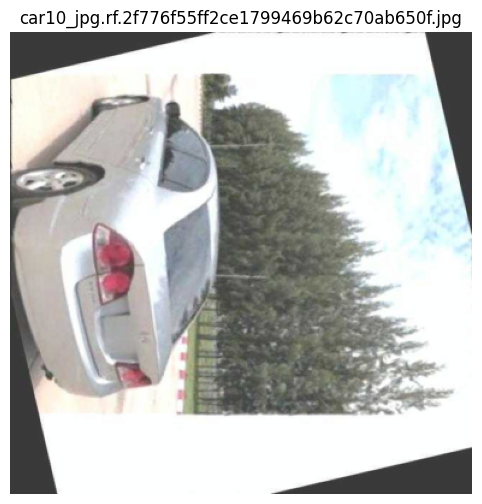

In [32]:

# Cell 10 — Sanity check: inspect one sample

sample = train_dataset[0]

print("Image name:", sample["image_name"])
print("pixel_values:", tuple(sample["pixel_values"].shape))
print("Number of masks:", len(sample["mask_labels"]))
print("Class labels:", sample["class_labels"].tolist())
print("Class names:", [
    id2label[int(class_id)]
    for class_id in sample["class_labels"]
])

image_tensor = sample["pixel_values"].permute(1, 2, 0).cpu().numpy()

# Undo ImageNet normalization for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

display_image = np.clip(image_tensor * std + mean, 0, 1)

plt.figure(figsize=(10, 6))
plt.imshow(display_image)
plt.title(sample["image_name"])
plt.axis("off")
plt.show()


In [33]:

# Cell 11 — Build model

set_seed(SEED)

config = Mask2FormerConfig.from_pretrained(MODEL_NAME)

config.num_queries = NUM_QUERIES
config.num_labels = NUM_CLASSES
config.id2label = id2label
config.label2id = label2id

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True,
)

model.to(DEVICE)

# Keep the same class weighting used in the baseline.
# The last value is the no-object class.
weights_list = [0.15] + [2.5] * (NUM_CLASSES - 1) + [1.0]

custom_weights = torch.tensor(
    weights_list,
    dtype=torch.float32,
    device=DEVICE,
)

if len(custom_weights) != NUM_CLASSES + 1:
    raise ValueError(
        f"Expected {NUM_CLASSES + 1} weights, got {len(custom_weights)}"
    )

model.criterion.empty_weight = custom_weights

print("Model loaded")
print("Queries:", model.config.num_queries)
print("Classes:", model.config.num_labels)


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded
Queries: 100
Classes: 23


In [34]:

# Cell 12 — Optimizer with a smaller LR for the backbone

backbone_parameters = []
main_parameters = []

for parameter_name, parameter in model.named_parameters():
    if not parameter.requires_grad:
        continue

    if "pixel_level_module.encoder" in parameter_name:
        backbone_parameters.append(parameter)
    else:
        main_parameters.append(parameter)

optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_parameters,
            "lr": BACKBONE_LR,
        },
        {
            "params": main_parameters,
            "lr": MAIN_LR,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

print("Backbone parameter groups:", len(backbone_parameters))
print("Main parameter groups:", len(main_parameters))
print("Backbone LR:", optimizer.param_groups[0]["lr"])
print("Main LR:", optimizer.param_groups[1]["lr"])


Backbone parameter groups: 225
Main parameter groups: 328
Backbone LR: 1e-05
Main LR: 5e-05


In [35]:

# Cell 13 — Warmup and cosine scheduler

TOTAL_TRAINING_STEPS = len(train_loader) * MAX_EPOCHS
WARMUP_STEPS = len(train_loader) * WARMUP_EPOCHS

scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_TRAINING_STEPS,
)

print("Total training steps:", TOTAL_TRAINING_STEPS)
print("Warmup steps:", WARMUP_STEPS)


Total training steps: 33550
Warmup steps: 2013


In [36]:

# Cell 14 — Helper: reconstruct semantic class map from GT masks

def build_ground_truth_class_map(
    mask_labels: torch.Tensor,
    class_labels: torch.Tensor,
) -> np.ndarray:
    height = mask_labels.shape[-2]
    width = mask_labels.shape[-1]

    class_map = np.full(
        (height, width),
        fill_value=255,
        dtype=np.int16,
    )

    masks_np = mask_labels.cpu().numpy()
    labels_np = class_labels.cpu().numpy()

    for mask, class_id in zip(masks_np, labels_np):
        class_map[mask > 0.5] = int(class_id)

    return class_map


In [37]:

# Cell 15 — Validation function

@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    processor,
    threshold: float = 0.5,
):
    model.eval()

    intersections = np.zeros(NUM_CLASSES, dtype=np.float64)
    unions = np.zeros(NUM_CLASSES, dtype=np.float64)
    gt_pixels = np.zeros(NUM_CLASSES, dtype=np.float64)
    pred_pixels = np.zeros(NUM_CLASSES, dtype=np.float64)

    total_correct_pixels = 0
    total_labeled_pixels = 0

    total_loss = 0.0
    number_of_batches = 0

    for batch in data_loader:
        pixel_values = batch["pixel_values"].to(
            DEVICE,
            non_blocking=True,
        )

        pixel_mask = batch.get("pixel_mask")
        if pixel_mask is not None:
            pixel_mask = pixel_mask.to(
                DEVICE,
                non_blocking=True,
            )

        mask_labels_device = [
            labels.to(DEVICE)
            for labels in batch["mask_labels"]
        ]

        class_labels_device = [
            labels.to(DEVICE)
            for labels in batch["class_labels"]
        ]

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
            mask_labels=mask_labels_device,
            class_labels=class_labels_device,
        )

        total_loss += float(outputs.loss.item())
        number_of_batches += 1

        target_sizes = [
            (
                batch["mask_labels"][index].shape[-2],
                batch["mask_labels"][index].shape[-1],
            )
            for index in range(len(batch["mask_labels"]))
        ]

        processed_results = processor.post_process_instance_segmentation(
            outputs,
            threshold=threshold,
            target_sizes=target_sizes,
        )

        for index, processed in enumerate(processed_results):
            gt_map = build_ground_truth_class_map(
                batch["mask_labels"][index],
                batch["class_labels"][index],
            )

            instance_map = processed["segmentation"].cpu().numpy()

            pred_map = np.full(
                instance_map.shape,
                fill_value=255,
                dtype=np.int16,
            )

            for segment in processed["segments_info"]:
                segment_id = int(segment["id"])
                class_id = int(segment["label_id"])

                pred_map[instance_map == segment_id] = class_id

            valid_gt = gt_map != 255

            total_correct_pixels += np.logical_and(
                valid_gt,
                gt_map == pred_map,
            ).sum()

            total_labeled_pixels += valid_gt.sum()

            for class_id in range(NUM_CLASSES):
                gt_binary = gt_map == class_id
                pred_binary = pred_map == class_id

                intersection = np.logical_and(
                    gt_binary,
                    pred_binary,
                ).sum()

                union = np.logical_or(
                    gt_binary,
                    pred_binary,
                ).sum()

                intersections[class_id] += intersection
                unions[class_id] += union
                gt_pixels[class_id] += gt_binary.sum()
                pred_pixels[class_id] += pred_binary.sum()

    per_class_iou = np.full(NUM_CLASSES, np.nan)
    per_class_dice = np.full(NUM_CLASSES, np.nan)
    per_class_precision = np.full(NUM_CLASSES, np.nan)
    per_class_recall = np.full(NUM_CLASSES, np.nan)

    for class_id in range(NUM_CLASSES):
        intersection = intersections[class_id]
        union = unions[class_id]
        gt_count = gt_pixels[class_id]
        pred_count = pred_pixels[class_id]

        if union > 0:
            per_class_iou[class_id] = intersection / union

        if gt_count + pred_count > 0:
            per_class_dice[class_id] = (
                2.0 * intersection / (gt_count + pred_count)
            )

        if pred_count > 0:
            per_class_precision[class_id] = (
                intersection / pred_count
            )

        if gt_count > 0:
            per_class_recall[class_id] = (
                intersection / gt_count
            )

    present_classes = gt_pixels > 0

    metrics = {
        "val_loss": total_loss / max(number_of_batches, 1),
        "mIoU": float(np.nanmean(per_class_iou[present_classes])),
        "mDice": float(np.nanmean(per_class_dice[present_classes])),
        "mPrecision": float(np.nanmean(per_class_precision[present_classes])),
        "mRecall": float(np.nanmean(per_class_recall[present_classes])),
        "pixel_accuracy": (
            float(total_correct_pixels / total_labeled_pixels)
            if total_labeled_pixels > 0
            else float("nan")
        ),
    }

    per_class_table = pd.DataFrame({
        "class_id": list(range(NUM_CLASSES)),
        "class_name": [
            id2label[class_id]
            for class_id in range(NUM_CLASSES)
        ],
        "gt_pixels": gt_pixels.astype(np.int64),
        "pred_pixels": pred_pixels.astype(np.int64),
        "IoU": per_class_iou,
        "Dice": per_class_dice,
        "Precision": per_class_precision,
        "Recall": per_class_recall,
    })

    metrics["per_class"] = per_class_table
    return metrics


In [38]:

# Cell 16 — Train one epoch

def train_one_epoch(
    model,
    data_loader,
    optimizer,
    scheduler,
    scaler,
    epoch_number: int,
):
    model.train()

    loss_sum = 0.0
    batch_count = 0
    start_time = time.time()

    for batch_index, batch in enumerate(data_loader):
        optimizer.zero_grad(set_to_none=True)

        pixel_values = batch["pixel_values"].to(
            DEVICE,
            non_blocking=True,
        )

        pixel_mask = batch.get("pixel_mask")
        if pixel_mask is not None:
            pixel_mask = pixel_mask.to(
                DEVICE,
                non_blocking=True,
            )

        mask_labels = [
            labels.to(DEVICE)
            for labels in batch["mask_labels"]
        ]

        class_labels = [
            labels.to(DEVICE)
            for labels in batch["class_labels"]
        ]

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda"),
        ):
            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                mask_labels=mask_labels,
                class_labels=class_labels,
            )

            loss = outputs.loss

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at batch {batch_index}: {loss.item()}"
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRADIENT_CLIP_NORM,
        )

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loss_sum += float(loss.item())
        batch_count += 1

        if batch_index % 50 == 0:
            print(
                f"Epoch {epoch_number:02d} | "
                f"Batch {batch_index:04d}/{len(data_loader):04d} | "
                f"Loss {loss.item():.4f} | "
                f"Backbone LR {optimizer.param_groups[0]['lr']:.2e} | "
                f"Main LR {optimizer.param_groups[1]['lr']:.2e}"
            )

    elapsed_seconds = time.time() - start_time

    return {
        "train_loss": loss_sum / max(batch_count, 1),
        "training_seconds": elapsed_seconds,
    }


In [39]:

# Cell 17 — Full training loop

best_miou = -float("inf")
best_epoch = None
epochs_without_improvement = 0
history = []

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda"),
)

for epoch in range(1, MAX_EPOCHS + 1):
    print("\n" + "=" * 80)
    print(f"Epoch {epoch}/{MAX_EPOCHS}")
    print("=" * 80)

    train_result = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        epoch_number=epoch,
    )

    print("\nRunning validation...")

    validation_result = evaluate_model(
        model=model,
        data_loader=val_loader,
        processor=processor,
        threshold=VALIDATION_THRESHOLD,
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_result["train_loss"],
        "val_loss": validation_result["val_loss"],
        "val_mIoU": validation_result["mIoU"],
        "val_mDice": validation_result["mDice"],
        "val_precision": validation_result["mPrecision"],
        "val_recall": validation_result["mRecall"],
        "val_pixel_accuracy": validation_result["pixel_accuracy"],
        "training_seconds": train_result["training_seconds"],
        "backbone_lr": optimizer.param_groups[0]["lr"],
        "main_lr": optimizer.param_groups[1]["lr"],
    }

    history.append(epoch_record)
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    print(
        f"Train loss:        {epoch_record['train_loss']:.4f}\n"
        f"Validation loss:   {epoch_record['val_loss']:.4f}\n"
        f"Validation mIoU:   {epoch_record['val_mIoU']:.4f}\n"
        f"Validation Dice:   {epoch_record['val_mDice']:.4f}\n"
        f"Validation Prec.:  {epoch_record['val_precision']:.4f}\n"
        f"Validation Recall: {epoch_record['val_recall']:.4f}\n"
        f"Pixel accuracy:    {epoch_record['val_pixel_accuracy']:.4f}"
    )

    current_miou = validation_result["mIoU"]

    if current_miou > best_miou + MIN_MIOU_IMPROVEMENT:
        best_miou = current_miou
        best_epoch = epoch
        epochs_without_improvement = 0

        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)

        validation_result["per_class"].to_csv(
            OUTPUT_DIR / "best_validation_per_class.csv",
            index=False,
        )

        metadata = {
            "experiment_name": "Mask2Former Experiment 2",
            "best_epoch": best_epoch,
            "best_validation_mIoU": best_miou,
            "model_name": MODEL_NAME,
            "num_classes": NUM_CLASSES,
            "num_queries": NUM_QUERIES,
            "batch_size": BATCH_SIZE,
            "main_learning_rate": MAIN_LR,
            "backbone_learning_rate": BACKBONE_LR,
            "weight_decay": WEIGHT_DECAY,
            "warmup_epochs": WARMUP_EPOCHS,
            "validation_threshold": VALIDATION_THRESHOLD,
            "gradient_clip_norm": GRADIENT_CLIP_NORM,
            "photometric_augmentation": USE_PHOTOMETRIC_AUGMENTATION,
            "seed": SEED,
        }

        with (OUTPUT_DIR / "experiment_metadata.json").open(
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(metadata, file, indent=2)

        print(
            f"\nNew best checkpoint saved: "
            f"epoch {best_epoch}, mIoU {best_miou:.4f}"
        )

    else:
        epochs_without_improvement += 1

        print(
            f"No meaningful improvement. "
            f"Patience: {epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping activated.")
        break

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nTraining finished")
print("Best epoch:", best_epoch)
print("Best validation mIoU:", best_miou)
print("Saved model:", OUTPUT_DIR.resolve())



Epoch 1/50
Epoch 01 | Batch 0000/0671 | Loss 121.5049 | Backbone LR 4.97e-09 | Main LR 2.48e-08
Epoch 01 | Batch 0050/0671 | Loss 125.4521 | Backbone LR 2.53e-07 | Main LR 1.27e-06
Epoch 01 | Batch 0100/0671 | Loss 120.4702 | Backbone LR 5.02e-07 | Main LR 2.51e-06
Epoch 01 | Batch 0150/0671 | Loss 110.7343 | Backbone LR 7.50e-07 | Main LR 3.75e-06
Epoch 01 | Batch 0200/0671 | Loss 93.2089 | Backbone LR 9.99e-07 | Main LR 4.99e-06
Epoch 01 | Batch 0250/0671 | Loss 61.9060 | Backbone LR 1.25e-06 | Main LR 6.23e-06
Epoch 01 | Batch 0300/0671 | Loss 56.9165 | Backbone LR 1.50e-06 | Main LR 7.48e-06
Epoch 01 | Batch 0350/0671 | Loss 54.8070 | Backbone LR 1.74e-06 | Main LR 8.72e-06
Epoch 01 | Batch 0400/0671 | Loss 45.2174 | Backbone LR 1.99e-06 | Main LR 9.96e-06
Epoch 01 | Batch 0450/0671 | Loss 38.1002 | Backbone LR 2.24e-06 | Main LR 1.12e-05
Epoch 01 | Batch 0500/0671 | Loss 38.0048 | Backbone LR 2.49e-06 | Main LR 1.24e-05
Epoch 01 | Batch 0550/0671 | Loss 34.5097 | Backbone LR 2.74

/tmp/ipykernel_126901/3987620572.py:153: RuntimeWarning: Mean of empty slice
  "mPrecision": float(np.nanmean(per_class_precision[present_classes])),


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


New best checkpoint saved: epoch 1, mIoU 0.0000

Epoch 2/50
Epoch 02 | Batch 0000/0671 | Loss 34.1278 | Backbone LR 3.34e-06 | Main LR 1.67e-05
Epoch 02 | Batch 0050/0671 | Loss 38.0457 | Backbone LR 3.59e-06 | Main LR 1.79e-05
Epoch 02 | Batch 0100/0671 | Loss 35.2845 | Backbone LR 3.84e-06 | Main LR 1.92e-05
Epoch 02 | Batch 0150/0671 | Loss 29.1320 | Backbone LR 4.08e-06 | Main LR 2.04e-05
Epoch 02 | Batch 0200/0671 | Loss 25.2838 | Backbone LR 4.33e-06 | Main LR 2.17e-05
Epoch 02 | Batch 0250/0671 | Loss 18.2976 | Backbone LR 4.58e-06 | Main LR 2.29e-05
Epoch 02 | Batch 0300/0671 | Loss 27.6609 | Backbone LR 4.83e-06 | Main LR 2.41e-05
Epoch 02 | Batch 0350/0671 | Loss 28.8964 | Backbone LR 5.08e-06 | Main LR 2.54e-05
Epoch 02 | Batch 0400/0671 | Loss 24.0211 | Backbone LR 5.33e-06 | Main LR 2.66e-05
Epoch 02 | Batch 0450/0671 | Loss 19.8854 | Backbone LR 5.57e-06 | Main LR 2.79e-05
Epoch 02 | Batch 0500/0671 | Loss 24.8941 | Backbone LR 5.82e-06 | Main LR 2.91e-05
Epoch 02 | Batc

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


New best checkpoint saved: epoch 32, mIoU 0.7999

Epoch 33/50
Epoch 33 | Batch 0000/0671 | Loss 3.5725 | Backbone LR 3.20e-06 | Main LR 1.60e-05
Epoch 33 | Batch 0050/0671 | Loss 3.9708 | Backbone LR 3.18e-06 | Main LR 1.59e-05
Epoch 33 | Batch 0100/0671 | Loss 5.2081 | Backbone LR 3.16e-06 | Main LR 1.58e-05
Epoch 33 | Batch 0150/0671 | Loss 3.4091 | Backbone LR 3.13e-06 | Main LR 1.57e-05
Epoch 33 | Batch 0200/0671 | Loss 5.2304 | Backbone LR 3.11e-06 | Main LR 1.55e-05
Epoch 33 | Batch 0250/0671 | Loss 3.6081 | Backbone LR 3.09e-06 | Main LR 1.54e-05
Epoch 33 | Batch 0300/0671 | Loss 3.4855 | Backbone LR 3.06e-06 | Main LR 1.53e-05
Epoch 33 | Batch 0350/0671 | Loss 3.7042 | Backbone LR 3.04e-06 | Main LR 1.52e-05
Epoch 33 | Batch 0400/0671 | Loss 3.8612 | Backbone LR 3.02e-06 | Main LR 1.51e-05
Epoch 33 | Batch 0450/0671 | Loss 3.8332 | Backbone LR 3.00e-06 | Main LR 1.50e-05
Epoch 33 | Batch 0500/0671 | Loss 5.4680 | Backbone LR 2.97e-06 | Main LR 1.49e-05
Epoch 33 | Batch 0550/06

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


New best checkpoint saved: epoch 33, mIoU 0.8017

Epoch 34/50
Epoch 34 | Batch 0000/0671 | Loss 3.3904 | Backbone LR 2.89e-06 | Main LR 1.45e-05
Epoch 34 | Batch 0050/0671 | Loss 3.2308 | Backbone LR 2.87e-06 | Main LR 1.44e-05
Epoch 34 | Batch 0100/0671 | Loss 3.2696 | Backbone LR 2.85e-06 | Main LR 1.42e-05
Epoch 34 | Batch 0150/0671 | Loss 3.3977 | Backbone LR 2.83e-06 | Main LR 1.41e-05
Epoch 34 | Batch 0200/0671 | Loss 3.2488 | Backbone LR 2.80e-06 | Main LR 1.40e-05
Epoch 34 | Batch 0250/0671 | Loss 4.0872 | Backbone LR 2.78e-06 | Main LR 1.39e-05
Epoch 34 | Batch 0300/0671 | Loss 3.2658 | Backbone LR 2.76e-06 | Main LR 1.38e-05
Epoch 34 | Batch 0350/0671 | Loss 3.7324 | Backbone LR 2.74e-06 | Main LR 1.37e-05
Epoch 34 | Batch 0400/0671 | Loss 3.1746 | Backbone LR 2.72e-06 | Main LR 1.36e-05
Epoch 34 | Batch 0450/0671 | Loss 3.5482 | Backbone LR 2.69e-06 | Main LR 1.35e-05
Epoch 34 | Batch 0500/0671 | Loss 4.1408 | Backbone LR 2.67e-06 | Main LR 1.34e-05
Epoch 34 | Batch 0550/06

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


New best checkpoint saved: epoch 35, mIoU 0.8029

Epoch 36/50
Epoch 36 | Batch 0000/0671 | Loss 3.2979 | Backbone LR 2.31e-06 | Main LR 1.15e-05
Epoch 36 | Batch 0050/0671 | Loss 2.9893 | Backbone LR 2.29e-06 | Main LR 1.14e-05
Epoch 36 | Batch 0100/0671 | Loss 3.1991 | Backbone LR 2.27e-06 | Main LR 1.13e-05
Epoch 36 | Batch 0150/0671 | Loss 3.6621 | Backbone LR 2.25e-06 | Main LR 1.12e-05
Epoch 36 | Batch 0200/0671 | Loss 3.0373 | Backbone LR 2.23e-06 | Main LR 1.11e-05
Epoch 36 | Batch 0250/0671 | Loss 3.5312 | Backbone LR 2.21e-06 | Main LR 1.10e-05
Epoch 36 | Batch 0300/0671 | Loss 3.6502 | Backbone LR 2.18e-06 | Main LR 1.09e-05
Epoch 36 | Batch 0350/0671 | Loss 3.5389 | Backbone LR 2.16e-06 | Main LR 1.08e-05
Epoch 36 | Batch 0400/0671 | Loss 2.7818 | Backbone LR 2.14e-06 | Main LR 1.07e-05
Epoch 36 | Batch 0450/0671 | Loss 5.0452 | Backbone LR 2.12e-06 | Main LR 1.06e-05
Epoch 36 | Batch 0500/0671 | Loss 3.3002 | Backbone LR 2.10e-06 | Main LR 1.05e-05
Epoch 36 | Batch 0550/06

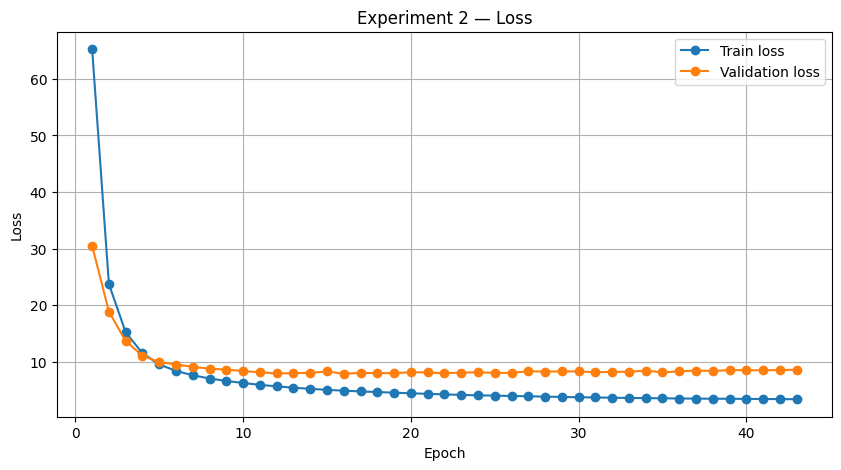

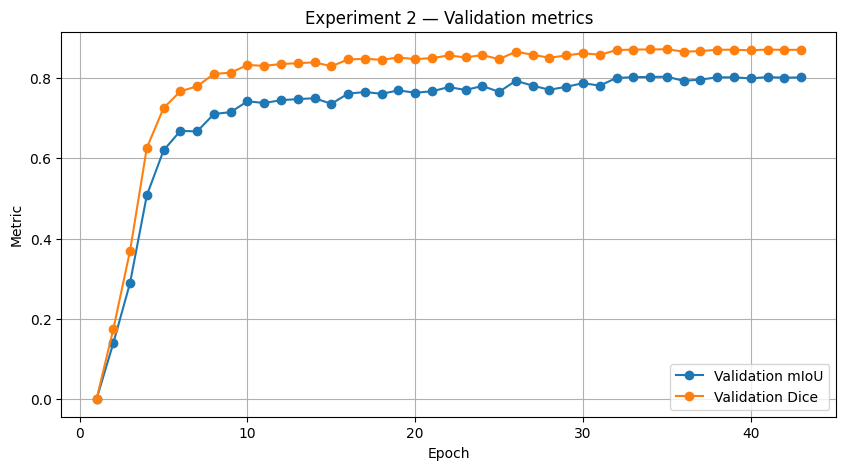

,epoch,train_loss,val_loss,val_mIoU,val_mDice,val_precision,val_recall,val_pixel_accuracy,training_seconds,backbone_lr,main_lr
34,35.0,3.534931,8.122865,0.802895,0.871394,0.92387,0.861698,0.932327,156.183333,0.000002,0.000012


In [40]:

# Cell 18 — Plot training history

history_df = pd.read_csv(HISTORY_CSV)

plt.figure(figsize=(10, 5))
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train loss",
)
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2 — Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    history_df["epoch"],
    history_df["val_mIoU"],
    marker="o",
    label="Validation mIoU",
)
plt.plot(
    history_df["epoch"],
    history_df["val_mDice"],
    marker="o",
    label="Validation Dice",
)
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Experiment 2 — Validation metrics")
plt.grid(True)
plt.legend()
plt.show()

best_history_row = history_df.loc[
    history_df["val_mIoU"].idxmax()
]

display(best_history_row.to_frame().T)


In [41]:

# Cell 19 — Load the best checkpoint and evaluate again

best_processor = AutoImageProcessor.from_pretrained(OUTPUT_DIR)

best_model = (
    Mask2FormerForUniversalSegmentation
    .from_pretrained(OUTPUT_DIR)
    .to(DEVICE)
)

best_results = evaluate_model(
    model=best_model,
    data_loader=val_loader,
    processor=best_processor,
    threshold=VALIDATION_THRESHOLD,
)

print("Best validation results")
print("-----------------------")
print(f"mIoU:           {best_results['mIoU']:.4f}")
print(f"mDice:          {best_results['mDice']:.4f}")
print(f"Precision:      {best_results['mPrecision']:.4f}")
print(f"Recall:         {best_results['mRecall']:.4f}")
print(f"Pixel accuracy: {best_results['pixel_accuracy']:.4f}")
print(f"Validation loss:{best_results['val_loss']:.4f}")

per_class_results = best_results["per_class"].sort_values(
    "IoU",
    ascending=False,
)

display(per_class_results)


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Best validation results
-----------------------
mIoU:           0.8029
mDice:          0.8714
Precision:      0.9239
Recall:         0.8617
Pixel accuracy: 0.9323
Validation loss:8.1211


,class_id,class_name,gt_pixels,pred_pixels,IoU,Dice,Precision,Recall
10,10,front_glass,2994350,2999254,0.933210,0.965451,0.964662,0.966242
8,8,front_bumper,8662730,8636212,0.914404,0.955288,0.956755,0.953826
20,20,tailgate,224020,211556,0.913493,0.954791,0.982917,0.928230
21,21,trunk,297884,304623,0.912017,0.953984,0.943432,0.964775
16,16,hood,3508139,3390080,0.900016,0.947377,0.963873,0.931436
3,3,back_left_door,234351,241000,0.885146,0.939074,0.926120,0.952396
14,14,front_right_door,294680,306210,0.883373,0.938075,0.920414,0.956427
2,2,back_glass,1112076,1101899,0.883159,0.937955,0.942286,0.933663
6,6,back_right_door,207580,203247,0.882705,0.937699,0.947694,0.927912
7,7,back_right_light,48810,51063,0.872560,0.931944,0.911384,0.953452


In [42]:

# Cell 20 — Compare Experiment 2 with the original baseline

BASELINE_MIOU = 0.7533
BASELINE_DICE = 0.7936
BASELINE_PRECISION = 0.7980
BASELINE_RECALL = 0.7934
BASELINE_PIXEL_ACCURACY = 0.9304

comparison = pd.DataFrame([
    {
        "Experiment": "Baseline",
        "mIoU": BASELINE_MIOU,
        "Dice": BASELINE_DICE,
        "Precision": BASELINE_PRECISION,
        "Recall": BASELINE_RECALL,
        "Pixel Accuracy": BASELINE_PIXEL_ACCURACY,
    },
    {
        "Experiment": "Experiment 2",
        "mIoU": best_results["mIoU"],
        "Dice": best_results["mDice"],
        "Precision": best_results["mPrecision"],
        "Recall": best_results["mRecall"],
        "Pixel Accuracy": best_results["pixel_accuracy"],
    },
])

comparison["mIoU improvement"] = (
    comparison["mIoU"] - BASELINE_MIOU
)

display(comparison)

improvement = best_results["mIoU"] - BASELINE_MIOU

if improvement > 0:
    print(f"Experiment 2 improved mIoU by {improvement:.4f}")
else:
    print(f"Experiment 2 did not improve mIoU. Difference: {improvement:.4f}")


,Experiment,mIoU,Dice,Precision,Recall,Pixel Accuracy,mIoU improvement
0,Baseline,0.753300,0.793600,0.79800,0.793400,0.930400,0.000000
1,Experiment 2,0.802895,0.871394,0.92387,0.861698,0.932327,0.049595


Experiment 2 improved mIoU by 0.0496



## פירוש הניסוי

הניסוי נחשב מוצלח אם ה־validation mIoU של ה־checkpoint הטוב ביותר גבוה מה־baseline, ולא רק אם ה־training loss נמוך יותר.

שימי לב:

- אם המודל נעצר לפני 50 epochs, זה תקין. המטרה היא לשמור את ה־epoch הטוב ביותר.
- אם Experiment 2 משתפר, השלב הבא יכול להיות Experiment 2B עם שינויי תאורה עדינים בלבד.
- אם הוא אינו משתפר, אפשר לבצע ניסוי נפרד במשקלי המחלקות או ב־backbone גדול יותר.
- את מחלקת `object` אפשר להסיר בשלב מאוחר יותר ולאמן מחדש עם 22 מחלקות.


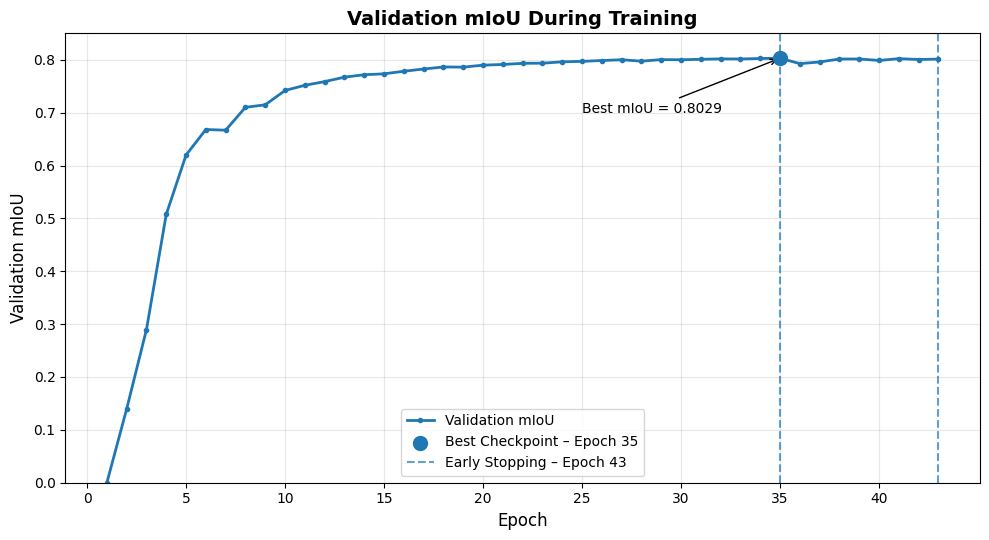

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Validation mIoU values taken directly from the saved notebook output
val_miou = [
    0.0000,
    0.1393,
    0.2896,
    0.5076,
    0.6198,
    0.6681,
    0.6668,
    0.7101,
    0.7148,
    0.7419,
    0.7517,
    0.7587,
    0.7671,
    0.7717,
    0.7734,
    0.7783,
    0.7825,
    0.7864,
    0.7861,
    0.7898,
    0.7911,
    0.7933,
    0.7935,
    0.7961,
    0.7970,
    0.7986,
    0.8000,
    0.7974,
    0.8003,
    0.8000,
    0.8009,
    0.8017,
    0.8015,
    0.8024,
    0.8029,
    0.7927,
    0.7958,
    0.8014,
    0.8015,
    0.7987,
    0.8021,
    0.8005,
    0.8013
]

epochs = np.arange(1, len(val_miou) + 1)

best_epoch = 35
early_stop_epoch = 43
best_value = val_miou[best_epoch - 1]

plt.figure(figsize=(10, 5.5))

plt.plot(
    epochs,
    val_miou,
    marker="o",
    markersize=3,
    linewidth=2,
    label="Validation mIoU"
)

# Best checkpoint
plt.scatter(
    best_epoch,
    best_value,
    s=100,
    zorder=5,
    label=f"Best Checkpoint – Epoch {best_epoch}"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    alpha=0.7
)

# Early stopping
plt.axvline(
    x=early_stop_epoch,
    linestyle="--",
    alpha=0.7,
    label=f"Early Stopping – Epoch {early_stop_epoch}"
)

plt.annotate(
    f"Best mIoU = {best_value:.4f}",
    xy=(best_epoch, best_value),
    xytext=(25, 0.70),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title(
    "Validation mIoU During Training",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation mIoU", fontsize=12)

plt.xticks(range(0, 44, 5))
plt.ylim(0, 0.85)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()